# Ray autoscaling recipe

A 100-run Monte Carlo dispatched through [`RayPool`](https://astro-tools.github.io/gmat-sweep/api/#gmat_sweep.backends.RayPool) against a local `ray.init()`. The local Ray runtime stands in for an autoscaling Ray cluster — same `ray` API, same task model, same submit/await flow. The [Ray autoscaling recipe page](https://astro-tools.github.io/gmat-sweep/recipes/ray-autoscaling/) shows how to point `RayPool` at a real autoscaling cluster instead; everything in this notebook works the same way against that backend.

## Set up the run

Reuse [notebook 04's injection-dispersion fixture](https://astro-tools.github.io/gmat-sweep/examples/04_monte_carlo_dispersion/) — a parking orbit, an injection burn `Inj` in VNB, a `CoastTime` variable for the parking-orbit phase, and a fixed post-burn propagation. The same script ships next to this notebook.

In [1]:
import os

# Set Ray env vars before `import ray`; the underlying constants are read
# once at import time. `RAY_ENABLE_UV_RUN_RUNTIME_ENV=0` disables Ray's
# auto-uv runtime_env hook, which would otherwise rebuild each worker's
# venv without the [ray] extra under `uv run`. `RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0`
# opts in to the future Ray default for non-GPU workloads (silences a
# transitional FutureWarning).
os.environ.setdefault("RAY_ENABLE_UV_RUN_RUNTIME_ENV", "0")
os.environ.setdefault("RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO", "0")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import ray
from gmat_run import locate_gmat

from gmat_sweep import monte_carlo
from gmat_sweep.backends import RayPool

install = locate_gmat()
script_path = Path("injection_dispersion.script").resolve()

print(f"GMAT version: {install.version}")
print(f"Script:       {script_path.name}")
print(f"Exists:       {script_path.exists()}")

GMAT version: R2026a
Script:       injection_dispersion.script
Exists:       True


## Bring up a local Ray runtime

`ray.init(num_cpus=4)` starts a single-node Ray instance — head, raylet, and four worker slots — in this Python process. On a real cluster, this single line becomes `ray.init(address="ray://<head-host>:10001")` and the rest of the notebook runs unchanged.

Disable the dashboard and driver-side log forwarding to keep notebook output uncluttered.

In [2]:
ray.init(num_cpus=4, include_dashboard=False, log_to_driver=False)

2026-05-07 18:46:34,166	INFO worker.py:2012 -- Started a local Ray instance.


Python version:,3.12.3
Ray version:,2.55.1


## Define the perturbations

Same four-axis perturbation cube as notebook 04, just at a smaller `n` so the notebook runs quickly even on a laptop:

- `CoastTime.Value` — normal, mean 600 s, 1-sigma 30 s.
- `Inj.Element1/2/3` — normal, mean (1.0, 0.0, 0.0) km/s, 1-sigma 5 m/s on each axis.

The Ray cluster handles the work distribution; `gmat-sweep` has nothing to configure on that side. Autoscaler-specific knobs (`min_workers`, `max_workers`) live in the cluster YAML and aren't visible to the driver.

In [3]:
SEED = 20260507
N = 100

perturb = {
    "CoastTime.Value": ("normal", 600.0, 30.0),
    "Inj.Element1": ("normal", 1.0, 0.005),
    "Inj.Element2": ("normal", 0.0, 0.005),
    "Inj.Element3": ("normal", 0.0, 0.005),
}

## Run the Monte Carlo

One [`monte_carlo()`](https://astro-tools.github.io/gmat-sweep/api/#gmat_sweep.monte_carlo) call with `backend=RayPool()` dispatches all 100 runs as Ray tasks, drains the per-run outcomes in completion order, and returns the aggregated `(run_id, time)`-MultiIndexed DataFrame. `RayPool()` with no arguments uses the running Ray instance — the local one we just started, or, on a real cluster, the one `ray.init(address=...)` connected to.

In [4]:
df = monte_carlo(
    script_path,
    n=N,
    perturb=perturb,
    seed=SEED,
    backend=RayPool(),
    progress=False,
)
df.head()

Sat.UTCGregorian        Sat.X  \
run_id time                                                           
0      2026-01-01 00:00:00.000 2026-01-01 00:00:00.000  6993.000000   
       2026-01-01 00:01:00.000 2026-01-01 00:01:00.000  6978.333351   
       2026-01-01 00:04:38.880 2026-01-01 00:04:38.880  6678.425887   
       2026-01-01 00:08:32.021 2026-01-01 00:08:32.021  5951.551859   
       2026-01-01 00:09:46.330 2026-01-01 00:09:46.330  5638.203421   

                                      Sat.Y        Sat.Z __status  
run_id time                                                        
0      2026-01-01 00:00:00.000     0.000000     0.000000       ok  
       2026-01-01 00:01:00.000   398.015650   216.104866       ok  
       2026-01-01 00:04:38.880  1823.429333   990.041349       ok  
       2026-01-01 00:08:32.021  3228.459540  1752.910508       ok  
       2026-01-01 00:09:46.330  3637.460146  1974.979719       ok

In [5]:
df["__status"].value_counts()

__status
ok    1199
Name: count, dtype: int64

## Miss-distance histogram

Same arrival-cloud summary as notebook 04: take the final-step row per run, compute the Euclidean distance from each arrival point to the empirical mean arrival, and histogram the result. The shape of the dispersion is the property of the script and the perturbation cube — the backend just changes how the work was scheduled.

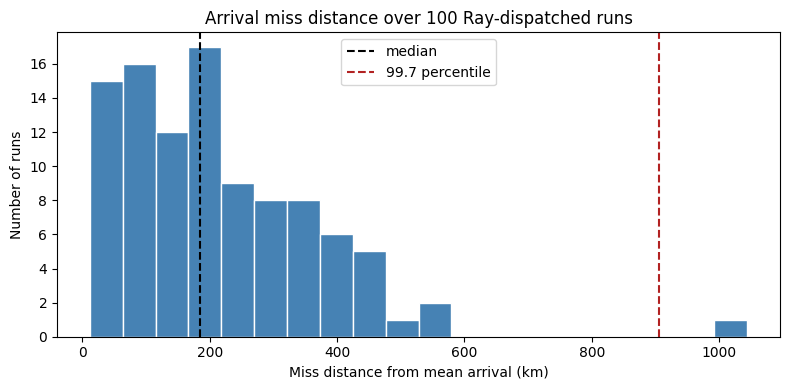

In [6]:
final = df.groupby(level="run_id").last()
arrivals = final[["Sat.X", "Sat.Y", "Sat.Z"]].to_numpy()
miss_km = np.linalg.norm(arrivals - arrivals.mean(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(miss_km, bins=20, color="steelblue", edgecolor="white")
ax.axvline(np.percentile(miss_km, 50), color="black", linestyle="--", label="median")
ax.axvline(np.percentile(miss_km, 99.7), color="firebrick", linestyle="--", label="99.7 percentile")
ax.set_xlabel("Miss distance from mean arrival (km)")
ax.set_ylabel("Number of runs")
ax.set_title(f"Arrival miss distance over {len(miss_km)} Ray-dispatched runs")
ax.legend()
fig.tight_layout()
plt.show()

## Tear down

Shut down the local Ray instance. On a real cluster this is a no-op — the cluster outlives the driver — and you'd skip this cell.

In [7]:
ray.shutdown()

## Going to an autoscaling cluster

The [Ray autoscaling recipe](https://astro-tools.github.io/gmat-sweep/recipes/ray-autoscaling/) covers the cluster YAML, the worker image discipline, and how the autoscaler responds to sweep load. The driver code is the same as this notebook — only the `ray.init(...)` line changes from `num_cpus=4` to `address="ray://<head-host>:10001"`.

For throughput numbers across the three backends, see the [reference benchmarks](https://astro-tools.github.io/gmat-sweep/benchmarks/).